In [19]:
import pandas as pd
import torch

from torch.utils.data import Dataset
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

In [20]:
DATA_DIR = Path("../data/raw")
SPLIT_DIR = Path("../data/processed")

train_df = pd.read_csv(SPLIT_DIR / "train.csv")
val_df = pd.read_csv(SPLIT_DIR / "validation.csv")
test_df = pd.read_csv(SPLIT_DIR / "test.csv")

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(6408, 7)
(1603, 7)
(2004, 7)


In [21]:
image_dirs = [
    DATA_DIR / "HAM10000_images_part_1",
    DATA_DIR / "HAM10000_images_part_2"
]


def find_image(image_id):

    for directory in image_dirs:

        image_path = directory / f"{image_id}.jpg"

        if image_path.exists():
            return image_path

    raise FileNotFoundError(
        f"Image not found: {image_id}"
    )

In [22]:
class_names = [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc"
]

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

print(class_to_idx)

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [23]:
class SkinDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_id = row["image_id"]
        label = row["dx"]

        image_path = find_image(image_id)

        image = Image.open(image_path).convert("RGB")

        label = class_to_idx[label]

        if self.transform:
            image = self.transform(image)

        return image, label

In [24]:
train_dataset = SkinDataset(train_df)

print("Dataset size:", len(train_dataset))

Dataset size: 6408


In [25]:
image, label = train_dataset[0]

print(type(image))
print(type(label))
print("Label:", label)

<class 'PIL.Image.Image'>
<class 'int'>
Label: 2


In [26]:
print("Image size:", image.size)
print("Image mode:", image.mode)
print("Label:", label)
print("Disease:", idx_to_class[label])

Image size: (600, 450)
Image mode: RGB
Label: 2
Disease: bkl


In [27]:
print("Dataset size:", len(train_dataset))
print("Image size:", image.size)
print("Image mode:", image.mode)
print("Label:", label)
print("Disease:", idx_to_class[label])

Dataset size: 6408
Image size: (600, 450)
Image mode: RGB
Label: 2
Disease: bkl


In [28]:
%pip install torchvision

Note: you may need to restart the kernel to use updated packages.


In [29]:
from torchvision import transforms

In [30]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [31]:
transforms.Resize((224, 224))

Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)

In [32]:
train_dataset = SkinDataset(train_df)

train_dataset = SkinDataset(
    train_df,
    transform=transform
)

image, label = train_dataset[0]

print(type(image))
print(image.shape)
print(image.dtype)
print(image.min())
print(image.max())

<class 'torch.Tensor'>
torch.Size([3, 224, 224])
torch.float32
tensor(0.1922)
tensor(0.9882)


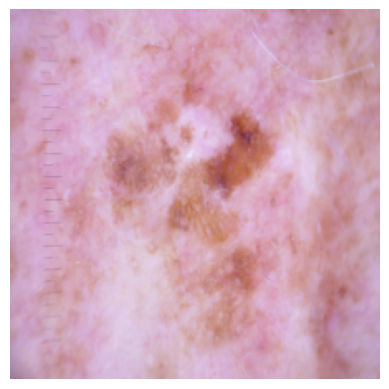

In [33]:
plt.imshow(image.permute(1, 2, 0))
plt.axis("off")
plt.show()

In [36]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = SkinDataset(
    train_df,
    transform=transform
)

image, label = train_dataset[0]

print("Type:", type(image))
print("Shape:", image.shape)
print("Dtype:", image.dtype)
print("Min:", image.min())
print("Max:", image.max())
print("Label:", label)
print("Disease:", idx_to_class[label])

Type: <class 'torch.Tensor'>
Shape: torch.Size([3, 224, 224])
Dtype: torch.float32
Min: tensor(-1.1604)
Max: tensor(2.5877)
Label: 2
Disease: bkl


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.160364..2.5877128].


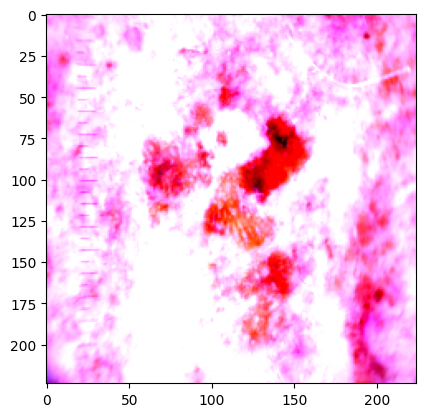

In [37]:
plt.imshow(image.permute(1, 2, 0))

In [38]:
from torch.utils.data import DataLoader

In [39]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle=True
)

In [40]:
val_dataset = SkinDataset(
    val_df,
    transform=transform
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [41]:
test_dataset = SkinDataset(
    test_df,
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [42]:
images, labels = next(iter(train_loader))

In [43]:
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

print("Images dtype:", images.dtype)
print("Labels dtype:", labels.dtype)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Images dtype: torch.float32
Labels dtype: torch.int64


In [44]:
def denormalize(image):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    image = image * std + mean

    return image.clamp(0, 1)

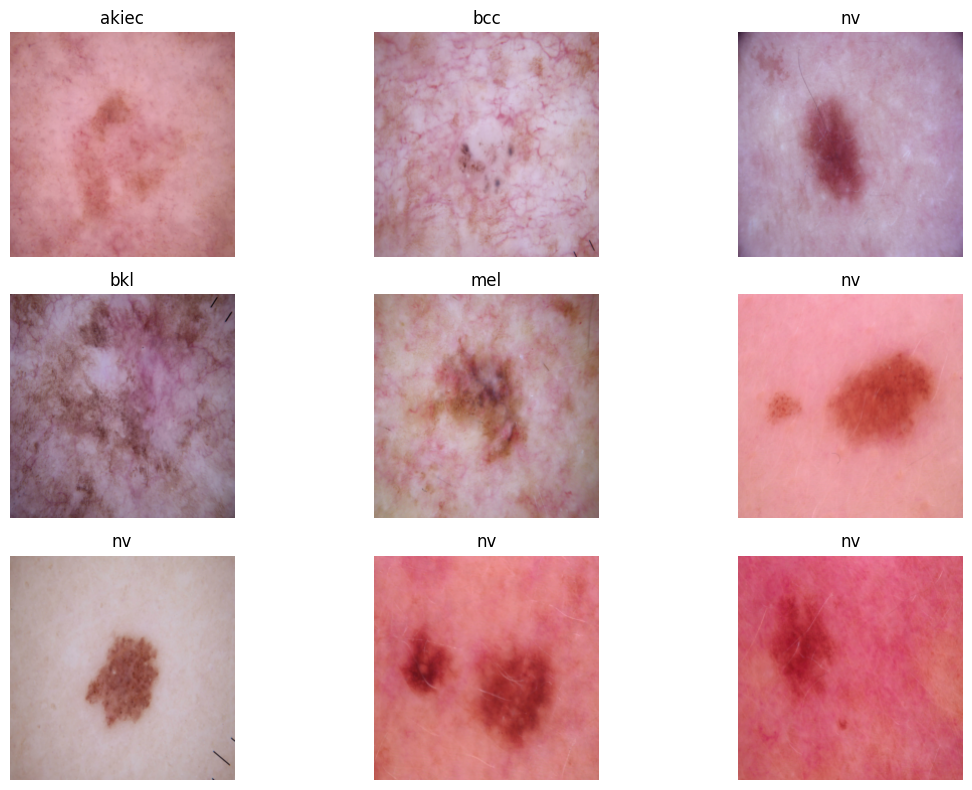

In [45]:
plt.figure(figsize=(12, 8))

for i in range(9):

    image = denormalize(images[i])

    image = image.permute(1, 2, 0)

    plt.subplot(3, 3, i + 1)

    plt.imshow(image)
    plt.title(idx_to_class[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [46]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Images dtype:", images.dtype)
print("Labels dtype:", labels.dtype)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Images dtype: torch.float32
Labels dtype: torch.int64
